In [1]:
import numpy as np;
import pandas as pd;
import matplotlib.pyplot as plt;
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler


**Bock, R. (2004). MAGIC Gamma Telescope [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C52C8B.**

Data are MC generated to simulate registration of high energy gamma particles in an atmospheric Cherenkov telescope

**Dataset Characteristics**
Multivariate

**Associated Tasks**
Classification

**Feature Type**
Real

**Instances**
19020

**Features**
10


In [2]:
cols = ["fLength", "fWidth", "fSize","fConc","fConc1","fAsym","fM3Long","fM3Trans","fAlpha","fDist","class"];
df = pd.read_csv("magic04.data",names=cols)
df.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


In [3]:
df["class"] = (df["class"] == "g").astype(int)
df.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,1
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,1
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,1
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,1
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,1


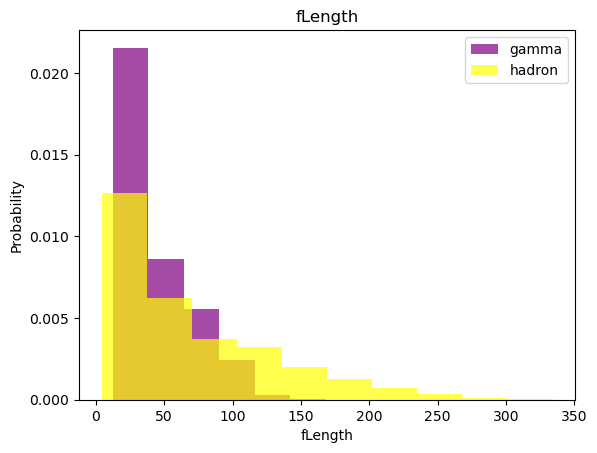

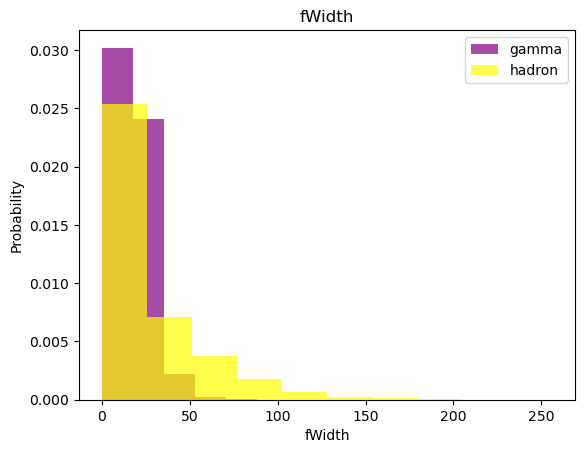

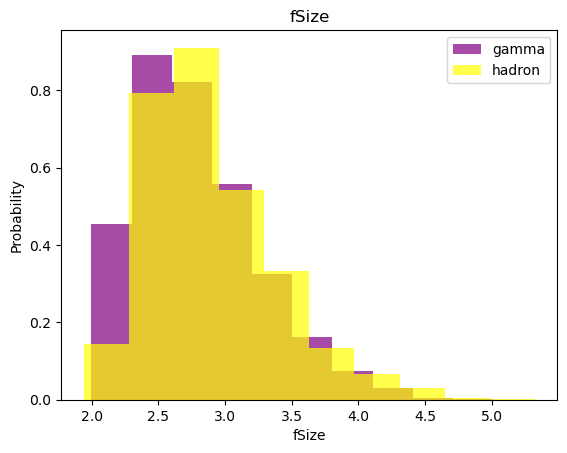

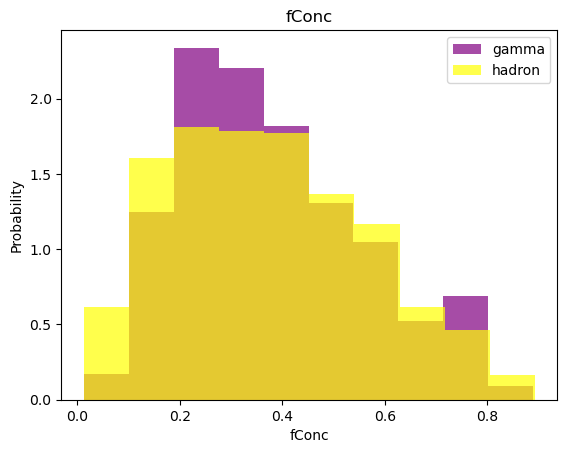

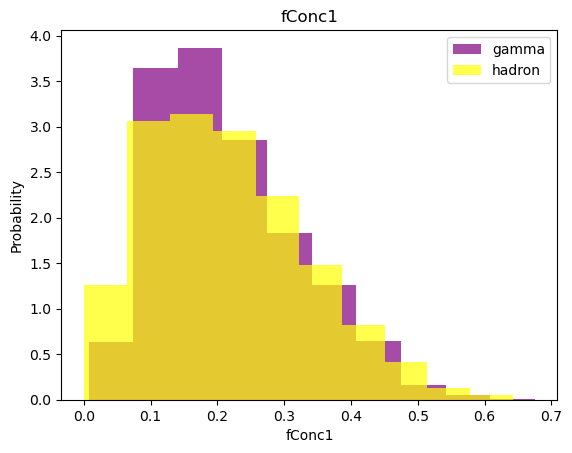

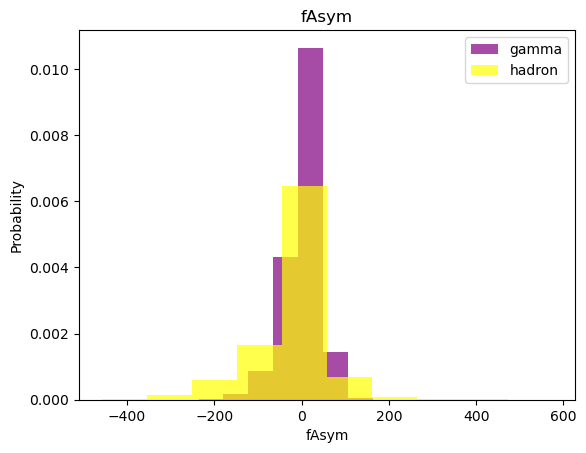

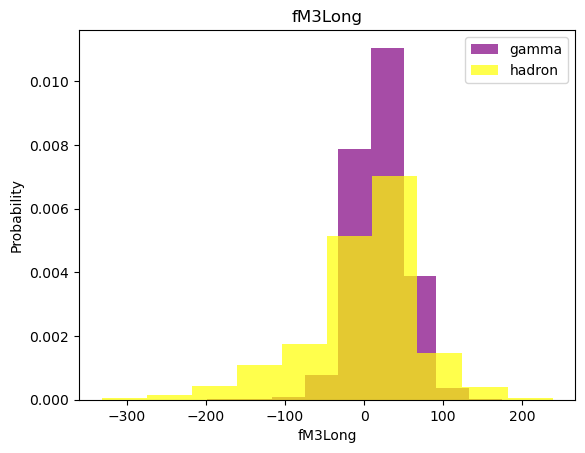

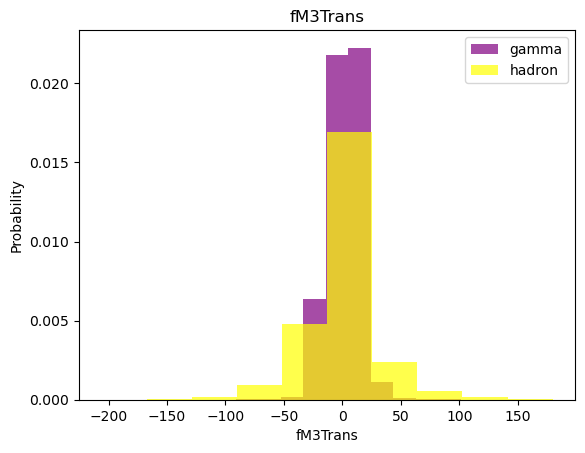

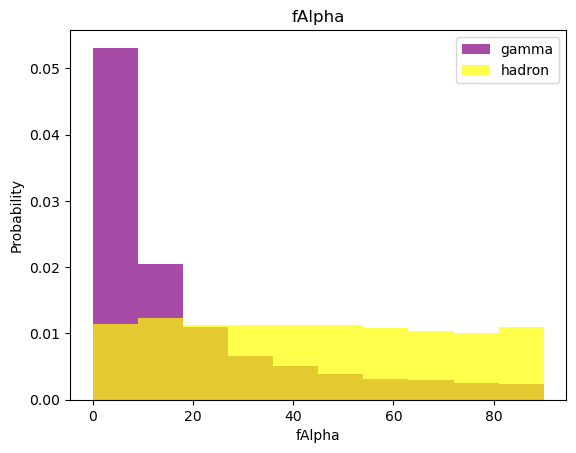

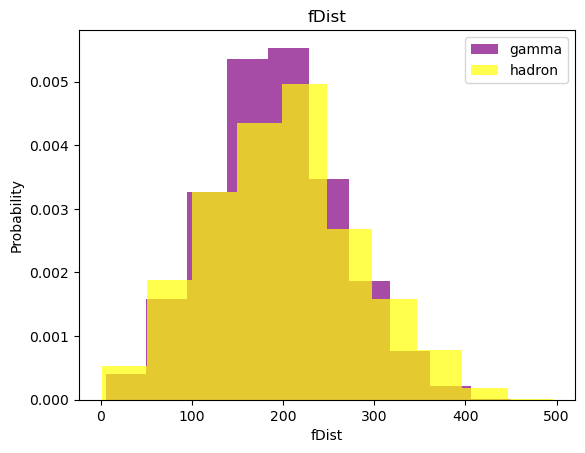

In [4]:
for label in cols[:-1]:
    plt.hist(df[df["class"]==1][label], color="purple", label="gamma", alpha=0.7, density=True)
    plt.hist(df[df["class"]==0][label], color="yellow", label="hadron",alpha=0.7, density=True)
    plt.title(label)
    plt.ylabel("Probability")
    plt.xlabel(label)
    plt.legend()
    plt.show()

In [5]:
train, valid, test = np.split(df.sample(frac=1), [int(0.6*len(df)), int(0.8*len(df))])

c:\ProgramData\anaconda3\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [6]:
train

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
5062,37.3038,11.8145,2.6871,0.3330,0.1799,-30.7648,-24.9632,5.8364,22.2935,176.1550,1
17232,83.9567,30.1932,2.7654,0.3561,0.2168,65.4790,76.9650,-19.4950,81.2130,123.8843,0
15210,65.4786,41.5616,3.3704,0.2872,0.1835,-21.3659,40.5399,18.4927,24.6642,333.7850,0
2311,56.0543,21.6876,3.0191,0.2105,0.1134,59.9613,49.8029,15.4890,6.6960,237.1040,1
2215,46.9609,24.6372,3.2460,0.1969,0.1030,43.7176,28.8646,-9.4719,5.7750,149.1400,1
...,...,...,...,...,...,...,...,...,...,...,...
3509,20.3836,6.9632,2.1508,0.7774,0.4346,20.8090,14.0899,5.5322,78.2360,166.4720,1
12233,86.4837,30.3894,3.8874,0.1256,0.0658,9.0636,87.3018,-17.2743,0.6946,248.6060,1
5752,68.6236,36.4003,3.8632,0.1133,0.0569,40.9586,53.6392,20.7744,3.3842,207.2980,1
2201,23.9122,22.0406,2.8642,0.3664,0.1921,22.0462,17.1313,8.2438,10.4948,120.4220,1


In [7]:
print(len(train[train["class"]==1])) # gamma
print(len(train[train["class"]==0])) # hadron

7401
4011


In [8]:
def scale_dataset(dataframe, oversample = False):
    X = dataframe[cols[:-1]].values
    y = dataframe[cols[-1]].values

    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    if oversample:
        ros = RandomOverSampler()
        X, y = ros.fit_resample(X, y)

    data = np.hstack((X, np.reshape(y, (-1,1))))

    return data, X, y


In [9]:
train, X_train, y_train = scale_dataset(train, oversample=True)

In [10]:
len(y_train)

14802

In [11]:
sum(y_train==1)  # gamma

np.int64(7401)

In [12]:
sum(y_train==0)  # hadron

np.int64(7401)

In [13]:
valid, X_valid, y_valid = scale_dataset(valid, oversample=False)
test, X_test, y_test = scale_dataset(test, oversample=False)

**Logistic Regression**

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [16]:
lg_model = LogisticRegression()
lg_model = lg_model.fit(X_train, y_train)

In [18]:
y_pred = lg_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.72      0.72      1375
           1       0.84      0.84      0.84      2429

    accuracy                           0.79      3804
   macro avg       0.78      0.78      0.78      3804
weighted avg       0.80      0.79      0.80      3804



In [19]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}\n")

Accuracy: 0.7950



In [20]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 993  382]
 [ 398 2031]]


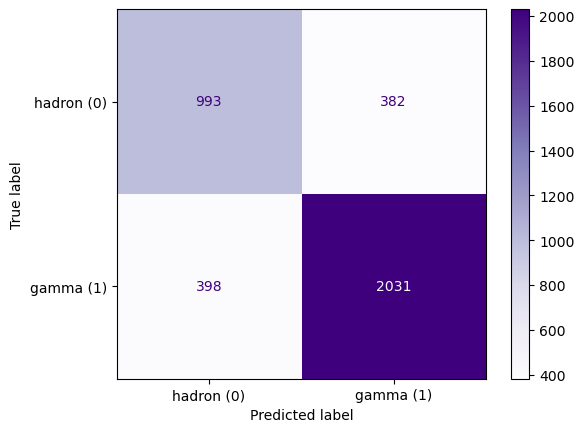

In [21]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["hadron (0)", "gamma (1)"])
disp.plot(cmap="Purples") 
plt.show()